In [1]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

import os, sys
from pathlib import Path
import functools
from typing import (
    Literal,
    NamedTuple,
    get_args
)

import extra_data as ex
from extra_data.components import AGIPD1M
from extra_geom import AGIPD_1MGeometry
from extra_data import by_index
import extra_speckle as esp
from extra_speckle.setup import Setup
import damnit

import numpy as np
from numpy.typing import ArrayLike, NDArray
import matplotlib.pyplot as plt
import h5py
import xarray as xr
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import curve_fit
from pybaselines import Baseline
from pyFAI.integrator.azimuthal import AzimuthalIntegrator
# import scienceplots

# plt.style.use('science')

N_A: float = 6.02214076e23
 
M_APOFERRITIN: float = 481_000.0  # g/mol, horse spleen (Gilbert et al. 1987)
V_BAR_APOFERRITIN: float = 0.738  # mL/g, 20 C
M_FE: float = 55.845
M_FEOOH: float = 88.852  # g/mol of core per Fe atom, ferrihydrite approximation
RHO_CORE: float = 4.1  # g/mL, ferritin ferrihydrite core
D_FERRITIN_NM: float = 12.0  # outer diameter of the cage
V_BAR_PEG: float = 0.833  # mL/g
RHO_WATER_25C: float = 0.99705  # g/mL

DB_VARIABLES = Literal["agipd_saxs", "jungfrau_waxs_jf1", "jungfrau_waxs_jf2", "jungfrau_waxs_combined"]

In [2]:
db = damnit.Damnit(10400)

In [3]:
run_nr = 425
bg_run_nr = 464
bg_run_nr_waxs = 55

In [4]:
def plot_saxs_series(dataset, ax, step=100, bg=None):
    q = dataset.q.values
    for i in range(0, len(dataset.trainId)-step, step):
        iq = dataset.isel(trainId=slice(i, i+step)).mean(["trainId", "pulseId"]).data
        if bg is not None:
            iq -= bg
        ax.loglog(q, iq)
    return ax


def read_intensity(run_nr, db, variable: DB_VARIABLES):
    assert variable in get_args(DB_VARIABLES), f"Variable {variable} not in {DB_VARIABLES}"
    return xr.open_dataset(db[run_nr].file, group=variable).intensity


def read_volume(run_nr, db):
     return xr.open_dataset(db[run_nr].file, group="droplet_fit").volume


def get_train_timestamps(run_nr, db):
    run = ex.RunDirectory(f"/gpfs/exfel/exp/MID/202601/p010400/raw/r{run_nr:04d}")
    ts = run.train_timestamps()
    return ts

    
def read_volume_series(run_series, db):
    v0 = xr.open_dataset(db[run_series[0]].file, group="droplet_fit").volume
    ts = get_train_timestamps(run_series[0], db)
    v = v0.assign_coords(time = ("trainId", ts))
    for run in run_series[1:]:
        _v = xr.open_dataset(db[run].file, group="droplet_fit").volume
        run = ex.RunDirectory(f"/gpfs/exfel/exp/MID/202601/p010400/raw/r{run:04d}")
        ts = run.train_timestamps()
        _v = _v.assign_coords(time = ("trainId", ts))
        v = xr.concat([v, _v], dim="trainId")
    return v

    
def gauss(x, mu, sigma, a):
    return a * np.exp(-(x-mu)**2/(2*sigma**2))


class FerritinProperties(NamedTuple):
    molar_mass: float  # g/mol, whole particle including core
    v_bar: float  # mL/g, mass-weighted shell + core
    iron_mass_fraction: float
    protein_mass_fraction: float  # apoferritin mass / whole-particle mass
 
 
def holoferritin_properties(
    n_fe: float = 1800.0,
    *,
    rho_core: float = RHO_CORE,
    m_apo: float = M_APOFERRITIN,
    v_bar_apo: float = V_BAR_APOFERRITIN,
) -> FerritinProperties:
    """Effective properties of iron-loaded ferritin at a given mean core loading.
 
    `n_fe` is the mean number of Fe atoms per molecule. Commercial horse spleen
    ferritin is typically 1600-2500; literature values span 1000-4500 and the
    distribution within one batch is broad. Measure it (ICP-MS, AAS, or A420/A280)
    rather than trusting this default.
    """
    m_core = n_fe * M_FEOOH
    m_total = m_apo + m_core
    v_bar = (m_apo * v_bar_apo + m_core / rho_core) / m_total
    return FerritinProperties(
        molar_mass=m_total,
        v_bar=v_bar,
        iron_mass_fraction=n_fe * M_FE / m_total,
        protein_mass_fraction=m_apo / m_total,
    )
 
 
class DropletComposition(NamedTuple):
    """Arrays broadcast to the shape of `volume`; scalars for the last three fields."""
 
    water_volume_fraction: NDArray[np.float64]
    water_mass_fraction: NDArray[np.float64]
    ferritin_mg_per_ml: NDArray[np.float64]  # whole-particle mass basis
    ferritin_molar: NDArray[np.float64]  # mol/L
    peg_mg_per_ml: NDArray[np.float64]
    peg_mg_per_ml_free_volume: NDArray[np.float64]  # per mL of PEG-accessible volume
    ferritin_volume_fraction_mass: NDArray[np.float64]  # from partial specific volume
    ferritin_volume_fraction_hs: NDArray[np.float64]  # from 12 nm hard spheres
    peg_volume_fraction: NDArray[np.float64]
    concentration_factor: NDArray[np.float64]
    volume_dry: float
    ferritin: FerritinProperties
 
 
def droplet_composition(
    volume: ArrayLike,
    volume_initial: float,
    *,
    ferritin_mg_per_ml_initial: float = 50.0,
    ferritin_basis: Literal["particle", "protein"] = "particle",
    peg_percent_wv_initial: float = 5.0,
    n_fe: float = 1800.0,
    d_ferritin_nm: float = D_FERRITIN_NM,
    v_bar_peg: float = V_BAR_PEG,
    rho_water: float = RHO_WATER_25C,
) -> DropletComposition:
    """Composition of a droplet that has evaporated from `volume_initial` to `volume`.
 
    Parameters
    ----------
    volume, volume_initial
        Volumes in mL (masses are reported per mL; only the ratio sets the fractions).
    ferritin_mg_per_ml_initial, ferritin_basis
        `"particle"`: the stated concentration is whole-ferritin mass, core included
        (what a gravimetric or vendor-lot figure usually means).
        `"protein"`: it is apoferritin mass only (what Lowry/Bradford/BCA report).
        The two differ by 1/protein_mass_fraction ~ 1.33 at 1800 Fe, which propagates
        directly into number density and every volume fraction below.
    n_fe
        Mean Fe atoms per molecule; sets the effective partial specific volume.
    """
    v = np.asarray(volume, dtype=np.float64)
    fer = holoferritin_properties(n_fe)
 
    c_fer0 = ferritin_mg_per_ml_initial * 1e-3  # g/mL, on the stated basis
    if ferritin_basis == "protein":
        c_fer0 /= fer.protein_mass_fraction  # convert to whole-particle mass
    c_peg0 = peg_percent_wv_initial * 10.0 * 1e-3  # g/mL
 
    mass_ferritin = c_fer0 * volume_initial
    mass_peg = c_peg0 * volume_initial
    vol_ferritin_mass = mass_ferritin * fer.v_bar
    vol_peg = mass_peg * v_bar_peg
    volume_dry = float(vol_ferritin_mass + vol_peg)
 
    n_particles = mass_ferritin / fer.molar_mass * N_A
    v_hs_ml = np.pi / 6.0 * (d_ferritin_nm * 1e-7) ** 3  # nm -> cm, cm^3 == mL
    vol_ferritin_hs = n_particles * v_hs_ml
 
    v_safe = np.where(v >= volume_dry, v, np.nan)
    volume_water = v_safe - volume_dry
    mass_water = rho_water * volume_water
    factor = volume_initial / v_safe
 
    phi_hs = vol_ferritin_hs / v_safe
    peg_nominal = peg_percent_wv_initial * 10.0 * factor
 
    return DropletComposition(
        water_volume_fraction=volume_water / v_safe,
        water_mass_fraction=mass_water / (mass_water + mass_ferritin + mass_peg),
        ferritin_mg_per_ml=c_fer0 * 1e3 * factor,
        ferritin_molar=n_particles / N_A / (v_safe * 1e-3),
        peg_mg_per_ml=peg_nominal,
        peg_mg_per_ml_free_volume=peg_nominal / (1.0 - phi_hs),
        ferritin_volume_fraction_mass=vol_ferritin_mass / v_safe,
        ferritin_volume_fraction_hs=phi_hs,
        peg_volume_fraction=vol_peg / v_safe,
        concentration_factor=factor,
        volume_dry=volume_dry,
        ferritin=fer,
    )


def volume_to_deff_sq(V):
    """Effective sphere-equivalent diameter squared, from volume."""
    D_eff = (6.0 * V / np.pi) ** (1.0 / 3.0)
    return D_eff ** 2


def deff_sq_to_volume(D2):
    """Inverse of volume_to_deff_sq: back to volume from D_eff^2."""
    D_eff = np.sqrt(D2)
    return (np.pi / 6.0) * D_eff ** 3

    
def piecewise_D2(t, D0_sq, k1, k2, t_star):
    """
    Continuous piecewise-linear D^2(t):
      t <= t_star : D0_sq - k1*t                (D2-law / evaporation regime)
      t >  t_star : D0_sq - k1*t_star - k2*(t-t_star)   (post-evaporation regime)
    k1, k2 are evaporation rate constants (>=0 for shrinking droplet).
    """
    t = np.asarray(t)
    branch1 = D0_sq - k1 * t
    branch2 = (D0_sq - k1 * t_star) - k2 * (t - t_star)
    return np.where(t <= t_star, branch1, branch2)

    
def fit_D2_law(t, V, t_star_guess=None, bounds=None):
    """
    t : array of times
    V : array of volumes (same length)
    Returns fit params (D0_sq, k1, k2, t_star) and covariance.
    """
    t = np.asarray(t, dtype=float)
    D2 = volume_to_deff_sq(np.asarray(V, dtype=float))

    if t_star_guess is None:
        t_star_guess = t[len(t) // 2]

    p0 = [D2[0], 
          (D2[0] - D2[len(D2)//2]) / (t_star_guess - t[0] + 1e-12),
          1e-3,
          t_star_guess]

    if bounds is None:
        bounds = ([0, 0, -np.inf, t.min()],
                  [np.inf, np.inf, np.inf, t.max()])

    popt, pcov = curve_fit(piecewise_D2, t, D2, p0=p0, bounds=bounds, maxfev=20000)
    return popt, pcov


def style_plot(ax: plt.Axes = None, ylabel: str = r"$I(q)~$(a.u.)", xlabel: str = r"$q~$(nm$^{-1}$)") -> None:
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_xlabel(xlabel, fontsize=14)
    handles, labels = ax.get_legend_handles_labels()
    if len(handles)>=1 and len(labels)>=1:
        ax.legend(handles, labels, fontsize=12)
    ax.tick_params(labelsize=12)
    ax.grid(which="major", ls="-", alpha=0.4)
    ax.grid(which="minor", ls="--", alpha=0.2)
    return

In [5]:
bg_waxs = read_intensity(bg_run_nr_waxs, db, variable="jungfrau_waxs_jf1")
avg_bg = bg_waxs.mean(["trainId", "cellId"])
q, iq_bg_waxs = avg_bg.q.values, avg_bg.data

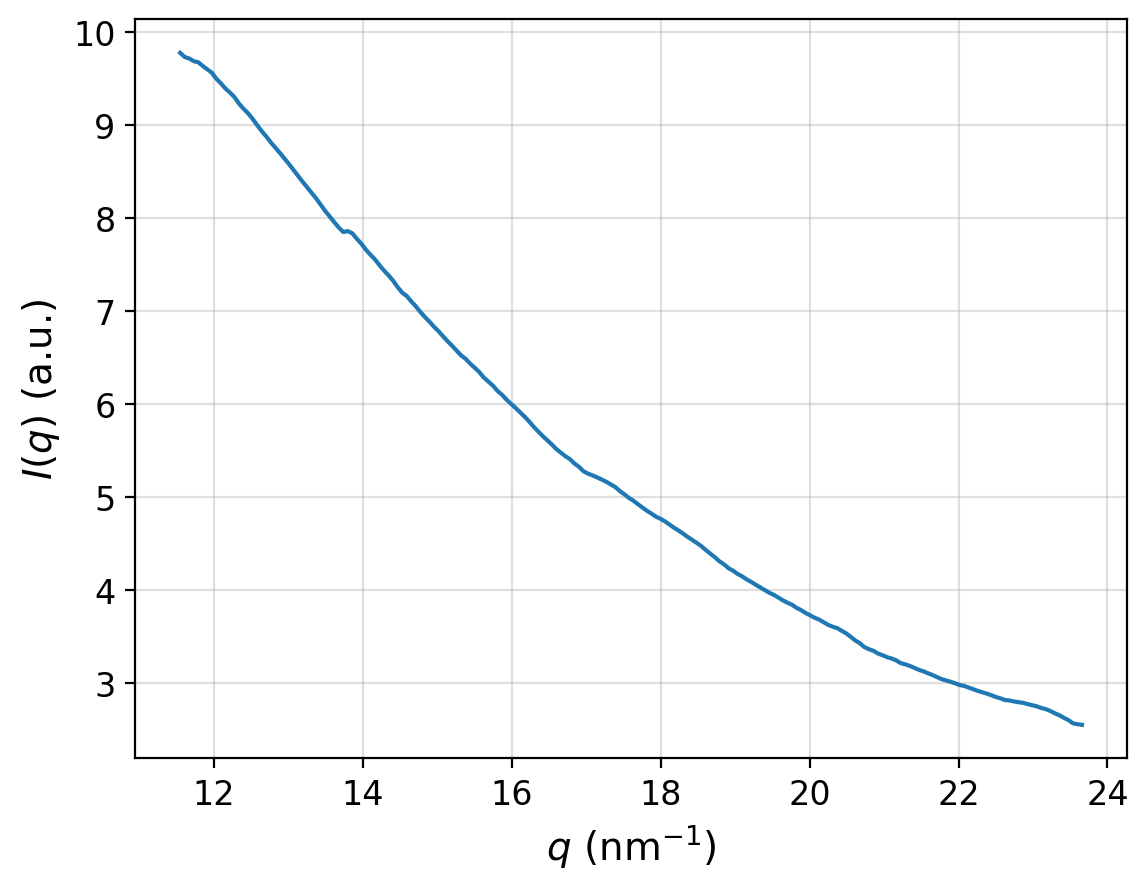

In [6]:
fig, ax = plt.subplots()
ax.plot(q, iq_bg_waxs)
style_plot(ax)
plt.show()

In [7]:
ex.open_run(run=423, proposal=10400)

OSError: [Errno 5] Unable to synchronously open file (file read failed: time = Fri Sep 18 14:25:31 2026
, filename = '/gpfs/exfel/exp/MID/202601/p010400/proc/r0423/CORR-R0423-AGIPD11-S00005.h5', file descriptor = 85, errno = 5, error message = 'Input/output error', buf = 0x7fffc8acda88, total read size = 8, bytes this sub-read = 8, offset = 0)

In [9]:
import h5py

with h5py.File('/gpfs/exfel/exp/MID/202601/p010400/proc/r0423/CORR-R0423-AGIPD11-S00005.h5', 'r') as f:
    print(f.keys())

OSError: [Errno 5] Unable to synchronously open file (file read failed: time = Fri Sep 18 14:19:50 2026
, filename = '/gpfs/exfel/exp/MID/202601/p010400/proc/r0423/CORR-R0423-AGIPD11-S00005.h5', file descriptor = 86, errno = 5, error message = 'Input/output error', buf = 0x7fffc4cfb108, total read size = 8, bytes this sub-read = 8, offset = 0)

In [19]:
run_range = list(range(423, 433))

v = read_volume_series(run_range, db)
timedelta = (v.time - v.isel(trainId=0).time).astype(float)*1e-9
# popt, pcov = fit_D2_law(timedelta, v/v[0], t_star_guess=timedelta[len(timedelta)//2])
t_star = popt[-1]
v_fit = deff_sq_to_volume(piecewise_D2(timedelta, *popt))

# fig, ax = plt.subplots()
# ax.plot(timedelta / popt[-1], v/v[0], label="data")
# # ax.plot(timedelta / popt[-1], v_fit, label="fit")
# style_plot(ax, xlabel="$t/t^*$", ylabel="$V/V_0$")
# plt.show()

OSError: [Errno 5] Unable to synchronously open file (file read failed: time = Fri Sep 18 14:11:46 2026
, filename = '/gpfs/exfel/exp/MID/202601/p010400/raw/r0423/RAW-R0423-AGIPD14-S00000.h5', file descriptor = 81, errno = 5, error message = 'Input/output error', buf = 0x7ffdd79bb098, total read size = 8, bytes this sub-read = 8, offset = 0)

In [18]:
colors = plt.cm.viridis(np.linspace(0, 1, len(run_range)))

water_ring = (q>8)&(q<24)

peak_pos = []
rel_time = []

t0 = get_train_timestamps(run_range[0], db)[0]

fig, ax = plt.subplots()
for idx, run_nr in enumerate(run_range):
    waxs = read_intensity(run_nr, db, variable="jungfrau_waxs_jf1")
    ts = get_train_timestamps(run_nr, db)
    timedelta = ((ts - t0).astype(float)*1e-9).mean()
    waxs = waxs.where(waxs.data > 0).dropna("trainId")
    v = read_volume(run_nr, db).data
    wf = droplet_composition(v, v[0]).water_mass_fraction.mean()
    pulse_avg = waxs.mean("cellId")
    avg = pulse_avg.isel(trainId=np.s_[::10]).mean("trainId")
    q, iq = avg.q.values, avg.data
    # iq = gaussian_filter1d(iq, 3)
    # trains.append(pulse_avg.isel(trainId=tr_idx).trainId.values)
    # iq_bg_sub = iq/0.98/(0.48*wf) - iq_bg_waxs*0.5/0.98
    iq_bg_sub = iq
    base = Baseline(q)
    bkg, params = base.arpls(iq_bg_sub, lam=1e2)
    x = q[water_ring]
    y = bkg[water_ring]
    popt, pcov = curve_fit(gauss, q[water_ring], bkg[water_ring], p0=[20, 1, 1], bounds=[[0, 0, -np.inf], [22, np.inf, np.inf]])
    peak_pos.append(popt[0])
    rel_time.append(timedelta/t_star)
    # plt.plot(q[water_ring], bkg[water_ring]*v.mean(), color=colors[idx])
    ax.plot(q, iq_bg_sub+2, color=colors[idx], label=f"$t/t^*={timedelta/t_star:.2f}$")
    # plt.vlines(popt[0], ymin=0, ymax=1.5, color=colors[idx], lw=1.5)
    # plt.vlines(q[water_ring][np.argmax(bkg[water_ring])], ymin=0, ymax=1.5, color=colors[idx], lw=1.5)
    # plt.plot(q[water_ring], gauss(q[water_ring], *popt) * v.mean())
# plt.plot(q, iq_bg_waxs*0.2, "k")
ax.plot(q, iq_bg_waxs/0.011)
style_plot(ax)
plt.show()

OSError: [Errno 5] Unable to synchronously open file (file read failed: time = Fri Sep 18 14:10:30 2026
, filename = '/gpfs/exfel/exp/MID/202601/p010400/raw/r0467/RAW-R0467-AGIPD01-S00007.h5', file descriptor = 83, errno = 5, error message = 'Input/output error', buf = 0x7ffdd79bb098, total read size = 8, bytes this sub-read = 8, offset = 0)

In [ ]:
peak_pos = np.asarray(peak_pos)
x = list(range(423, 433))
# peak_pos = peak_pos[peak_pos>13]
plt.plot(rel_time, peak_pos, 'o')
plt.xlabel("$t/t^*$")
plt.ylabel(r"$q~$(nm$^{-1}$)")
plt.show()

In [423]:
# Mass attenuation coefficients at 9.04 keV, cm^2/g.
MU_MASS_904: dict[str, float] = {
    "water": 6.785,
    "peg": 4.339,
    "protein": 4.548,
    "core": 142.8,  # FeOOH
}


def linear_attenuation(
    water_volume_fraction: NDArray[np.float64],
    ferritin_g_per_ml: NDArray[np.float64],
    peg_g_per_ml: NDArray[np.float64],
    protein_mass_fraction: float,
) -> NDArray[np.float64]:
    """mu in cm^-1 for the droplet interior."""
    return (
        MU_MASS_904["water"] * RHO_WATER_25C * water_volume_fraction
        + MU_MASS_904["peg"] * peg_g_per_ml
        + MU_MASS_904["protein"] * ferritin_g_per_ml * protein_mass_fraction
        + MU_MASS_904["core"] * ferritin_g_per_ml * (1.0 - protein_mass_fraction)
    )

In [424]:
bg_saxs = read_intensity(bg_run_nr, db, variable="agipd_saxs")

In [425]:
avg_bg = bg_saxs.isel(trainId=0).mean("pulseId")
v_bg_saxs = read_volume(bg_run_nr, db).data
comp = droplet_composition(v, v[0], ferritin_mg_per_ml_initial=0)
mu_bg = linear_attenuation(
    comp.water_volume_fraction,
    comp.ferritin_mg_per_ml * 1e-3,
    comp.peg_mg_per_ml * 1e-3,
    comp.ferritin.protein_mass_fraction,
)
d_um = xr.open_dataset(db[bg_run_nr].file, group="droplet_fit").radius.sel(dim="x").data.mean()
t_bg = np.exp(-mu_bg * d_um*1e-3).mean()
iq_bg_saxs = avg_bg.data

In [634]:
saxs = read_intensity(423, db, variable="agipd_saxs")

In [620]:
mipt = saxs.median(["q", "pulseId"])

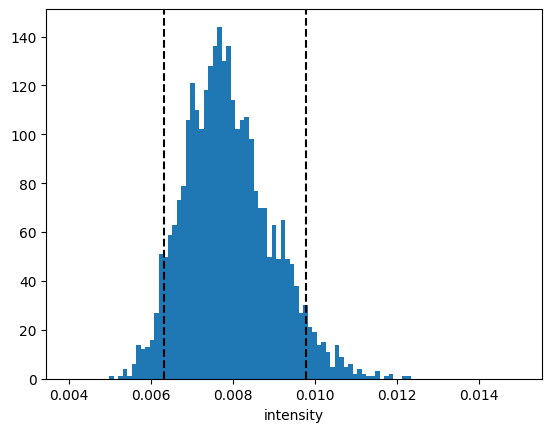

In [621]:
mipt.plot.hist(bins=100, range=(4e-3, 1.5e-2))
plt.axvline(mipt.quantile(0.05), color='k', ls='--')
plt.axvline(mipt.quantile(0.95), color='k', ls='--')
plt.show()

In [626]:
mipt_filtered = mipt.where((mipt<mipt.quantile(0.95))&(mipt>mipt.quantile(0.05)), drop=True)

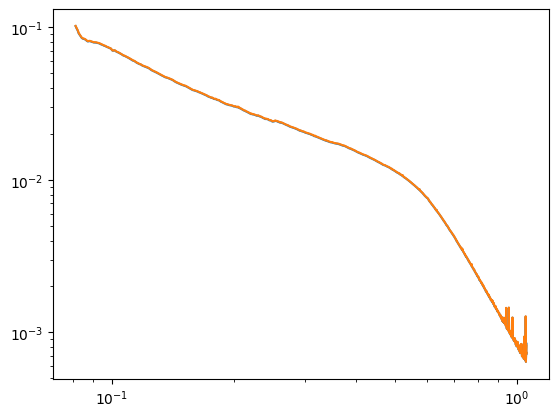

In [635]:
saxs = read_intensity(423, db, variable="agipd_saxs")
medipt = saxs.median(["q", "pulseId"])
medipt_filtered = medipt.where((medipt<medipt.quantile(0.95))&(medipt>medipt.quantile(0.05)), drop=True)
saxs_filtered = saxs.sel(trainId=medipt_filtered.trainId)

iq = saxs_filtered.mean(["trainId", "pulseId"])
plt.loglog(iq.q, iq)

iq = saxs.mean(["trainId", "pulseId"])
plt.loglog(iq.q, iq)

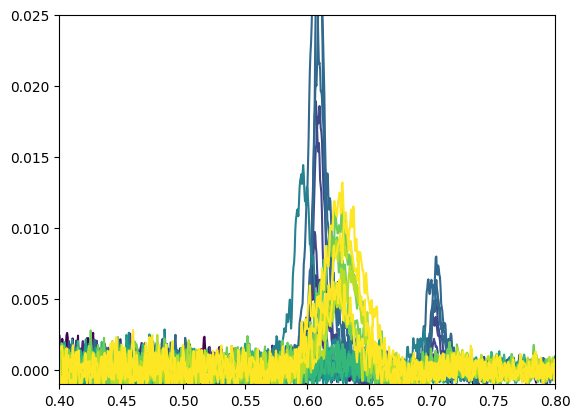

In [628]:
from scipy.signal import find_peaks

run_range = range(423, 433)
colors = plt.cm.viridis(np.linspace(0, 1, len(run_range)))

peaks_q = []
peaks_intensity = []


for idx, run_nr in enumerate(run_range):
    saxs = read_intensity(run_nr, db, variable="agipd_saxs")
    medipt = saxs.median(["q", "pulseId"])
    medipt_filtered = medipt.where((medipt<medipt.quantile(0.95))&(medipt>medipt.quantile(0.05)), drop=True)
    saxs_filtered = saxs.sel(trainId=medipt_filtered.trainId)
    for tr_idx in range(0, len(saxs_filtered.trainId), 1000):
        avg = saxs_filtered.isel(trainId=tr_idx).isel(pulseId=np.s_[::10]).mean("pulseId")
        # v = read_volume(run_nr, db).data
        # comp = droplet_composition(v, v[0])
        # mu_sample = linear_attenuation(
        #     comp.water_volume_fraction,
        #     comp.ferritin_mg_per_ml * 1e-3,
        #     comp.peg_mg_per_ml * 1e-3,
        #     comp.ferritin.protein_mass_fraction,
        # )
        # d_um = xr.open_dataset(db[run_nr].file, group="droplet_fit").radius.sel(dim="x").data.mean()
        # t_sample = np.exp(-mu_sample * d_um * 1e-3).mean()
        q, iq = avg.q.values, avg.data
        iq_bg_sub = iq - iq_bg_saxs*0.9
        q = q[iq_bg_sub>0]
        iq_bg_sub = iq_bg_sub[iq_bg_sub>0]
        base = Baseline(q)
        bkg, params = base.arpls(iq_bg_sub, lam=1e6)
        # plt.loglog(q, iq_bg_sub, color=colors[idx])
        iq_flat = iq_bg_sub-bkg
        ferritin_peak_range = (q>0.4)&(q<0.8)
        peaks, _ = find_peaks(iq_flat[ferritin_peak_range], prominence=0.002)
        peaks_q.append(q[ferritin_peak_range][peaks])
        peaks_intensity.append(iq_flat[ferritin_peak_range][peaks])
        plt.plot(q, iq_bg_sub-bkg, color=colors[idx])
    # plt.vlines(q[ferritin_peak_range][peaks], ymin=0, ymax=0.03)
# plt.loglog(q, iq_bg_saxs, 'k')
# plt.ylim(1e-3,)
plt.xlim(0.4, 0.8)
plt.ylim(-0.001, 0.025)
plt.show()

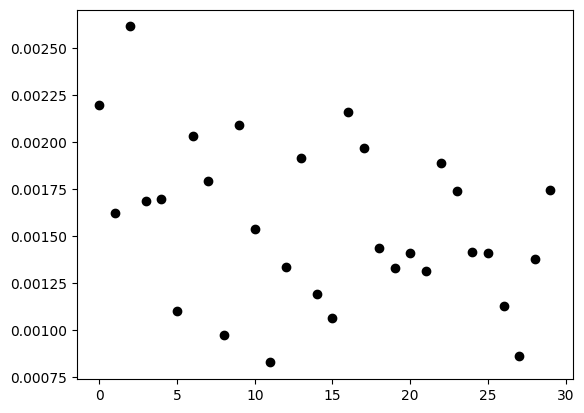

In [629]:
for idx, p in enumerate(peaks_intensity):
    if p.size > 0:
        plt.plot(idx, p[0], 'ok')
    else:
        plt.plot(idx, 0, 'ok')